In [1]:
%matplotlib notebook

from bertologist.data.Datasets import (
    ClusteredWordsDataset,
)
import pickle
import pandas as pd
import nltk
from matplotlib import pyplot as plt
from matplotlib import interactive
interactive(True)
import numpy as np
nltk.download("stopwords")
from nltk.corpus import stopwords

df = pickle.load(open("datasets/training_dataset_light.pkl", "rb"))

/home/lanver/python_venvs/master_thesis/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /home/lanver/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/lanver/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Let's prepare the dataframe for all the information we need

In [2]:
# Frequency
df['frequency'] = 1
df_frequency = df.groupby(['word']).agg({'salience_value': 'mean', 'frequency': 'sum'}).reset_index()
df_frequency = df_frequency.sort_values(by=['frequency'], ascending=False).reset_index(drop=True)
df_frequency['relative_frequency'] = df_frequency['frequency'] / df_frequency['frequency'].sum()
df_frequency['average_salience'] = df_frequency['salience_value']
df_frequency.drop(columns=['salience_value'], inplace=True)

# Stopwords
stop_words = stopwords.words("english")
stop_words.extend(["[CLS]", ["[SEP]"], "[PAD]", "[UNK]"]) # BERT tokens
# add html tags
stop_words.extend(['br', '<p>', '</p>', '<br>', '<br/>', '<br />', '<div>', '</div>', '<span>', '</span>', '<li>', '</li>', '<ul>', '</ul>', '<ol>', '</ol>', '<a>', '</a>', '<b>', '</b>', '<i>', '</i>', '<strong>', '</strong>', '<em>', '</em>', '<h1>', '</h1>', '<h2>', '</h2>', '<h3>', '</h3>', '<h4>', '</h4>', '<h5>', '</h5>', '<h6>', '</h6>', '<blockquote>', '</blockquote>', '<pre>', '</pre>', '<code>', '</code>', '<hr>', '<img>', '<table>', '</table>', '<tr>', '</tr>', '<td>', '</td>', '<th>', '</th>', '<caption>', '</caption>', '<thead>', '</thead>', '<tbody>', '</tbody>', '<tfoot>', '</tfoot>', '<form>', '</form>', '<input>', '<textarea>', '</textarea>', '<button>', '</button>', '<select>', '</select>', '<option>', '</option>', '<label>', '</label>', '<fieldset>', '</fieldset>', '<legend>', '</legend>', '<iframe>', '</iframe>', '<link>', '<meta>', '<script>', '</script>', '<style>', '</style>', '<title>', '</title>', '<head>', '</head>', '<body>', '</body>', '<html>', '</html>'])
stop_words.extend(['<', '>', '#', '/', '!', '?', '(', ')', '[', ']', '{', '}', '=', '+', '-', '*', '&', '^', '%', '$', '@', '~', '`', '|', ';', ':', '"', "'"])
stop_words.extend(['.', ',', r"'"])
df_frequency['is_stopword'] = df_frequency['word'].apply(lambda x: x in stop_words)


df_frequency.head()

,word,frequency,relative_frequency,average_salience,is_stopword
0,[CLS],15383,0.087120,0.030279,True
1,.,10650,0.060315,0.128427,True
2,the,8226,0.046587,0.027857,True
3,",",7876,0.044605,0.070402,True
4,of,3756,0.021272,0.027361,True


In [3]:
df_frequency[df_frequency["is_stopword"]].sort_values(by=['average_salience'], ascending=False).head()

,word,frequency,relative_frequency,average_salience,is_stopword
1,.,10650,0.060315,0.128427,True
9,',2553,0.014459,0.095349,True
14,<,1311,0.007425,0.083221,True
41,),494,0.002798,0.082434,True
17,br,1024,0.005799,0.081961,True


<IPython.core.display.Javascript object>


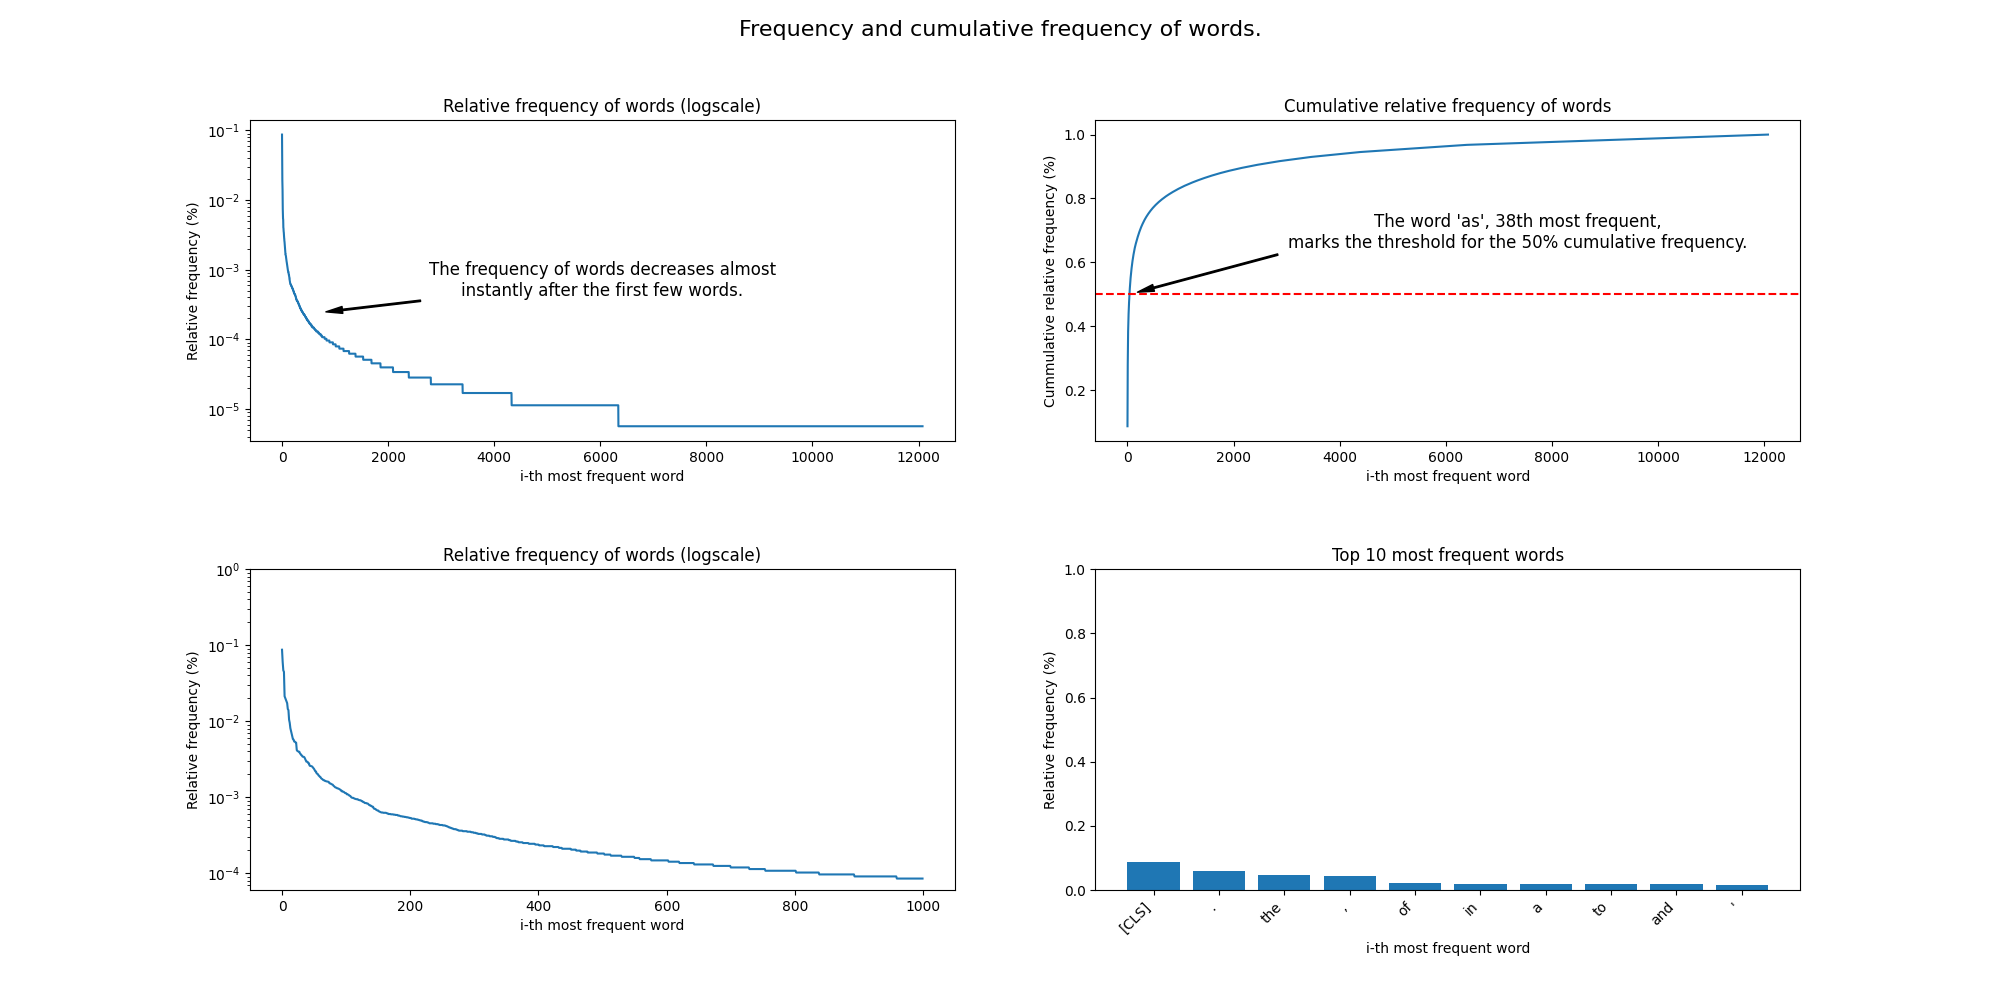

/tmp/ipykernel_48063/12199020.py:53: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  col.set_ylim(0, 1)
/tmp/ipykernel_48063/12199020.py:62: UserWarning: FixedFormatter should only be used together with FixedLocator
  col.set_xticklabels(df_frequency['word'][:10], rotation=45, ha="right")


Text(0.5, 0.98, 'Frequency and cumulative frequency of words.')

In [4]:
# find the position of the first value with the cummulative frequency > 0.5
half_x = (df_frequency['relative_frequency'].cumsum() > 0.5).argmax()
word_half_x = df_frequency['word'][half_x]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
fig.subplots_adjust(hspace=0.4)
for i, row in enumerate(ax):
    for j, col in enumerate(row):
        # defaults
        col.set_xlabel("i-th most frequent word")
        col.set_ylabel("Relative frequency (%)")
        if i == 0:
            if j == 0:
                col.set_yscale("log")
                col.plot(df_frequency['relative_frequency'])
                # change ylim to show the plot better
                col.set_yscale("log")
                col.set_title("Relative frequency of words (logscale)")
                col.annotate(
                    "The frequency of words decreases almost\ninstantly after the first few words.",
                    xy=(0.1, 0.4),
                    xytext=(0.5, 0.5),
                    # the text 
                    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=5),
                    horizontalalignment="center",
                    verticalalignment="center",
                    fontsize=12,
                    xycoords="axes fraction",
                )
            else:
                col.plot(df_frequency['relative_frequency'].cumsum())
                col.set_title("Cumulative relative frequency of words")
                col.set_ylabel("Cummulative relative frequency (%)")
                # show the x-value where the y value is 0.5
                col.axhline(y=0.5, color="r", linestyle="--")
                col.annotate(
                    f"The word '{word_half_x}', {half_x}th most frequent,\nmarks the threshold for the 50% cumulative frequency.",
                    xycoords="data",
                    textcoords="axes fraction",
                    xy=(half_x, 0.5),
                    xytext=(0.6, 0.65),
                    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=5),
                    horizontalalignment="center",
                    verticalalignment="center",
                    fontsize=12,
                )
        else:
            #col.set_xticks(range(1000))
            #col.set_xticklabels(counts.index[:1000])
            if j == 0:
                col.set_yscale("log")
                col.plot(df_frequency['relative_frequency'][:1000])
                col.set_ylim(0, 1)
                # change ylim to show the plot better
                col.set_yscale("log")
                col.set_title("Relative frequency of words (logscale)")
            else:
                # show bar chart of the top 10 words
                col.set_ylim(0, 1)
                col.bar(df_frequency['word'][:10], df_frequency['relative_frequency'][:10])
                col.set_title("Top 10 most frequent words")
                col.set_xticklabels(df_frequency['word'][:10], rotation=45, ha="right")
plt.show()

# Title
fig.suptitle("Frequency and cumulative frequency of words.", fontsize=16)

In [5]:
df_non_stopwords = df_frequency[~df_frequency['is_stopword']].reset_index(drop=True)
df_non_stopwords['relative_frequency'] = df_non_stopwords['frequency'] / df_non_stopwords['frequency'].sum()
df_non_stopwords['cumulative_frequency'] = df_non_stopwords['relative_frequency'].cumsum()
index_50percentile = (df_non_stopwords['cumulative_frequency'] > 0.5).argmax()
word_50percentile = df_non_stopwords['word'][index_50percentile]

<IPython.core.display.Javascript object>


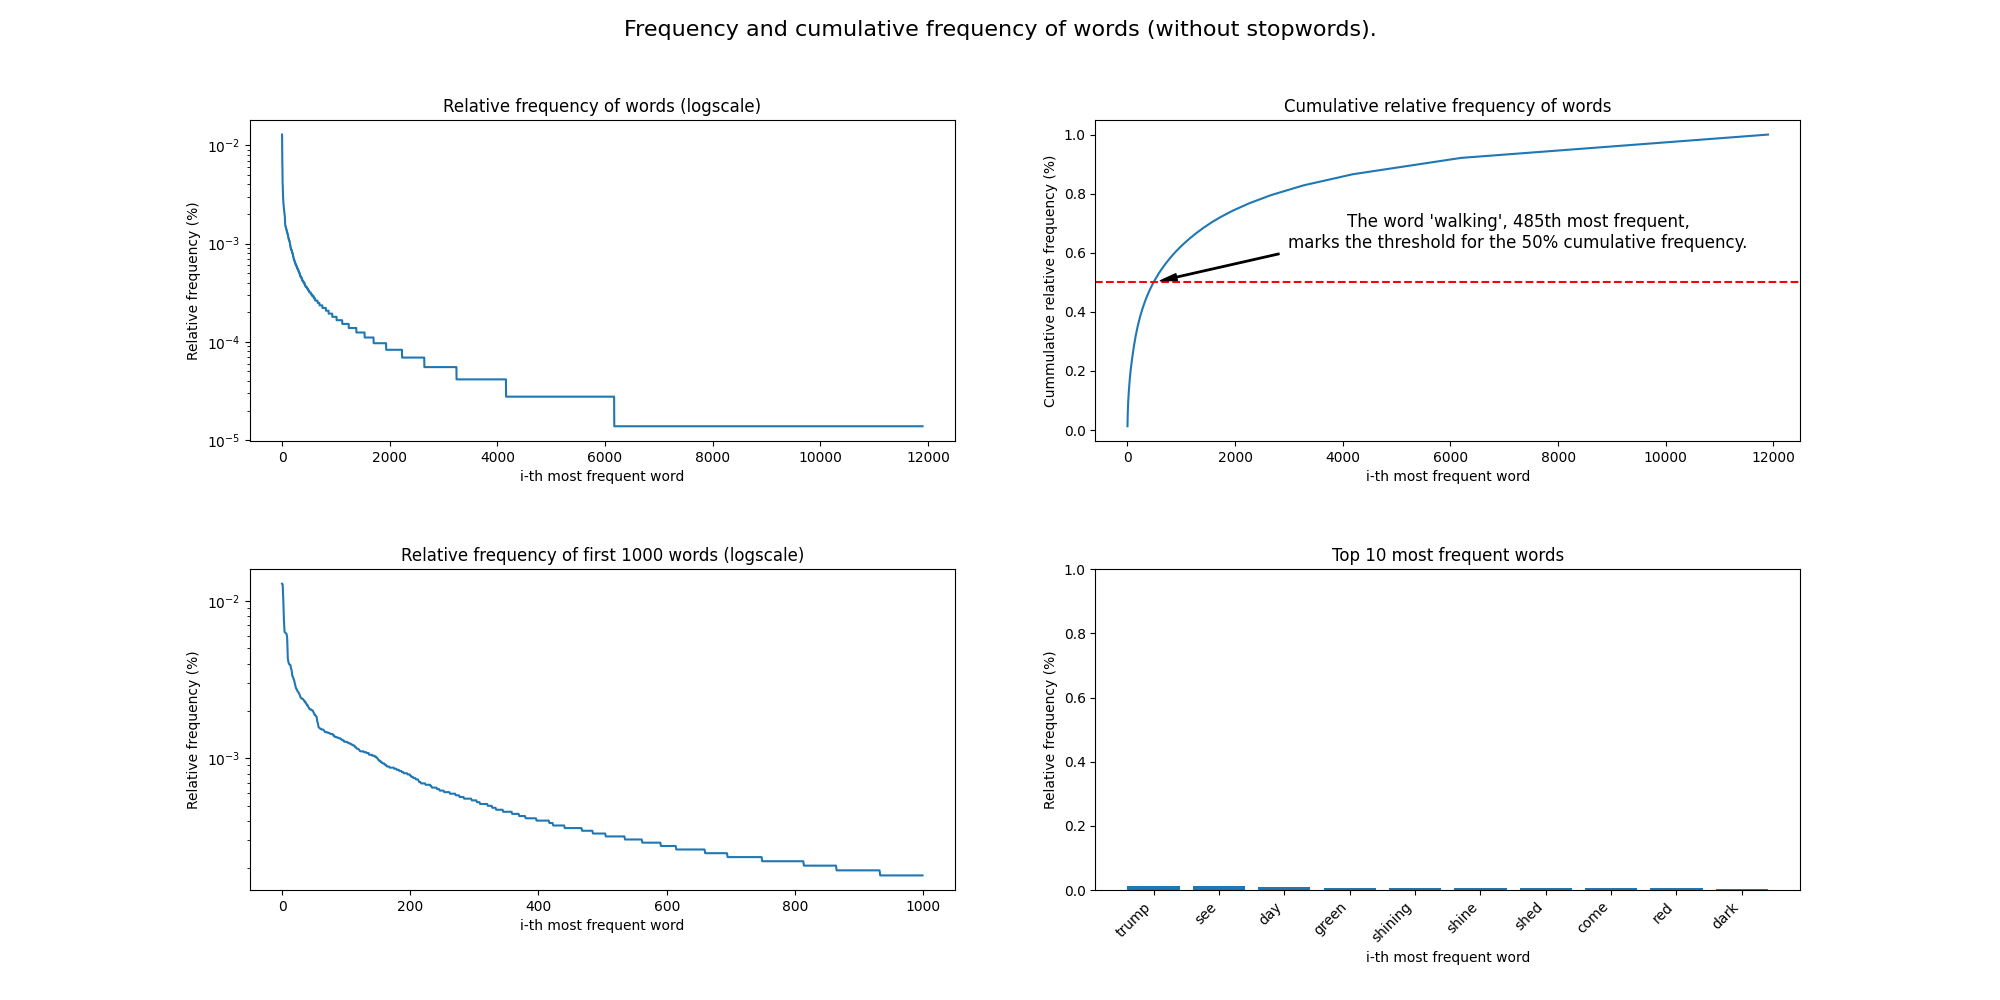

/tmp/ipykernel_48063/1770541622.py:46: UserWarning: FixedFormatter should only be used together with FixedLocator
  col.set_xticklabels(df_non_stopwords['word'][:10], rotation=45, ha="right")


Text(0.5, 0.98, 'Frequency and cumulative frequency of words (without stopwords).')

In [6]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
fig.subplots_adjust(hspace=0.4)
for i, row in enumerate(ax):
    for j, col in enumerate(row):
        # defaults
        col.set_xlabel("i-th most frequent word")
        col.set_ylabel("Relative frequency (%)")
        if i == 0:
            if j == 0:
                col.set_yscale("log")
                col.plot(df_non_stopwords['relative_frequency'])
                # change ylim to show the plot better
                col.set_yscale("log")
                col.set_title("Relative frequency of words (logscale)")
            else:
                col.plot(df_non_stopwords['cumulative_frequency'])
                col.set_title("Cumulative relative frequency of words")
                col.set_ylabel("Cummulative relative frequency (%)")
                # show the x-value where the y value is 0.5
                col.axhline(y=0.5, color="r", linestyle="--")
                col.annotate(
                    f"The word '{word_50percentile}', {index_50percentile}th most frequent,\nmarks the threshold for the 50% cumulative frequency.",
                    xycoords="data",
                    textcoords="axes fraction",
                    xy=(index_50percentile, 0.5),
                    xytext=(0.6, 0.65),
                    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=5),
                    horizontalalignment="center",
                    verticalalignment="center",
                    fontsize=12,
                )
        else:
            #col.set_xticks(range(1000))
            #col.set_xticklabels(counts.index[:1000])
            if j == 0:
                col.set_yscale("log")
                col.plot(df_non_stopwords['relative_frequency'][:1000])
                # change ylim to show the plot better
                col.set_yscale("log")
                col.set_title("Relative frequency of first 1000 words (logscale)")
            else:
                # show bar chart of the top 10 words
                col.set_ylim(0, 1)
                col.bar(df_non_stopwords['word'][:10], df_non_stopwords['relative_frequency'][:10])
                col.set_title("Top 10 most frequent words")
                col.set_xticklabels(df_non_stopwords['word'][:10], rotation=45, ha="right")
# Title
fig.suptitle("Frequency and cumulative frequency of words (without stopwords).", fontsize=16)

<IPython.core.display.Javascript object>


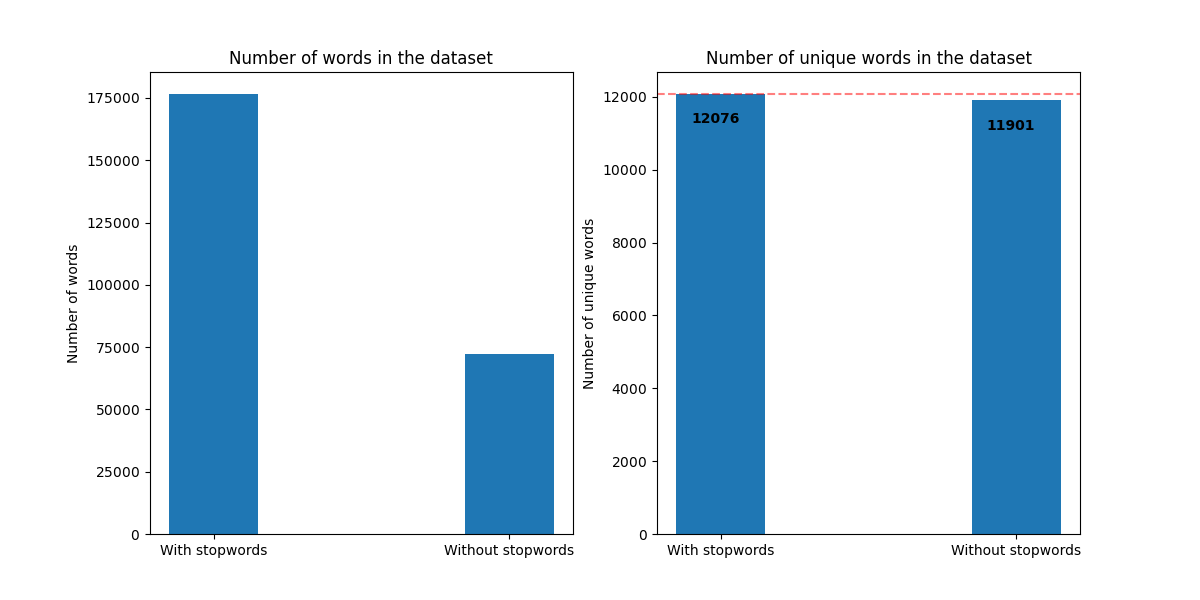

Text(0, 0.5, 'Number of unique words')

In [7]:
# plot the difference in number of words between the two datasets
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax[0].bar(["With stopwords", "Without stopwords"], [df_frequency['frequency'].sum(), df_non_stopwords['frequency'].sum()], width=0.3)
# the yticks in scientific notation
ax[0].ticklabel_format(style="sci", axis="y", useMathText=True)
ax[0].set_title("Number of words in the dataset")
ax[0].set_ylabel("Number of words")

# barplot of number of unique words
ax[1].bar(["With stopwords", "Without stopwords"], [len(df_frequency["word"].unique()), len(df_non_stopwords["word"].unique())], width=0.3)
# the yticks in scientific notation
# add labels to the bars
for i, v in enumerate([len(df_frequency["word"].unique()), len(df_non_stopwords["word"].unique())]):
    ax[1].text(i - 0.1, v - 800, str(v), color="black", fontweight="bold")
# hbar in the max value
ax[1].axhline(y=max([len(df_frequency["word"].unique()), len(df_non_stopwords["word"].unique())]), color="r", linestyle="--", alpha=0.5)
ax[1].ticklabel_format(style="sci", axis="y", useMathText=True)
ax[1].set_title("Number of unique words in the dataset")
ax[1].set_ylabel("Number of unique words")


In [8]:
df_frequency.head()

,word,frequency,relative_frequency,average_salience,is_stopword
0,[CLS],15383,0.087120,0.030279,True
1,.,10650,0.060315,0.128427,True
2,the,8226,0.046587,0.027857,True
3,",",7876,0.044605,0.070402,True
4,of,3756,0.021272,0.027361,True


<IPython.core.display.Javascript object>


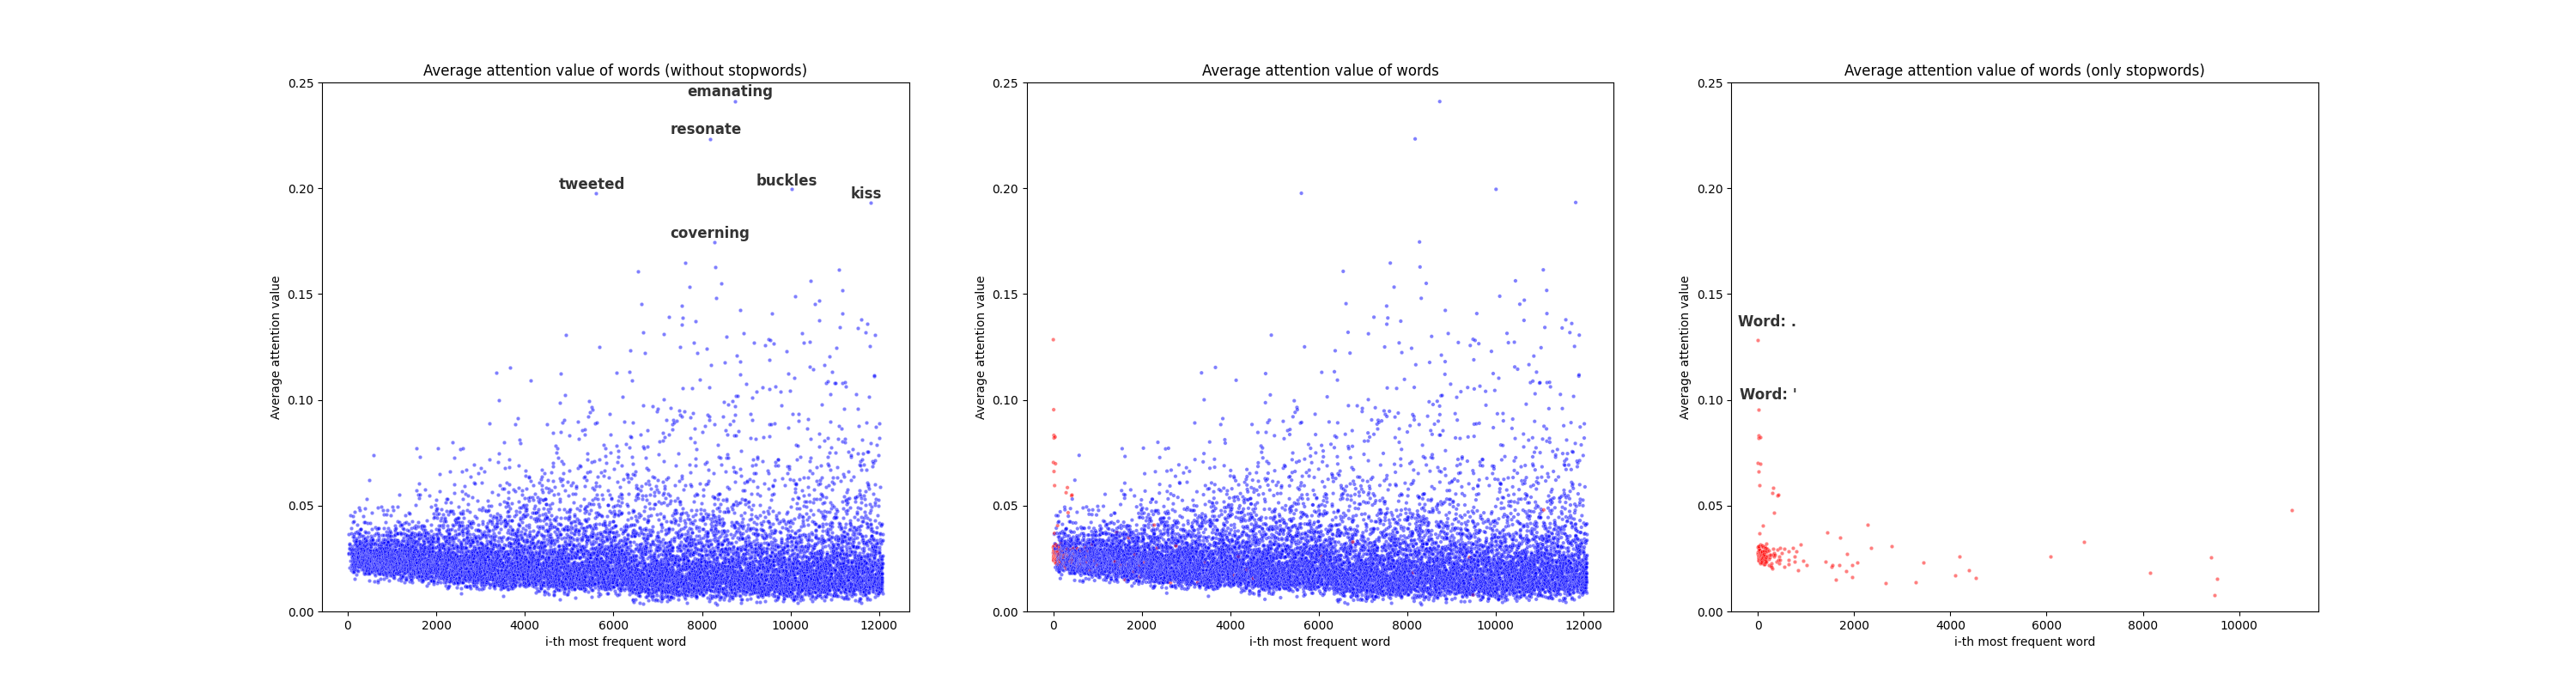

In [9]:
import statsmodels.api as sm
import seaborn as sns
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))
# red if it's a stopword, blue otherwise
color_list = ["red" if x else "blue" for x in df_frequency['is_stopword']]
# x is the row number, y is the average salience value
sns.scatterplot(data=df_frequency[df_frequency['is_stopword'] == False], x=df_frequency[df_frequency['is_stopword'] == False].index, y="average_salience", color='blue', ax=ax[0], s=10, alpha=0.5)
sns.scatterplot(data=df_frequency, x=df_frequency.index, y="average_salience", color=color_list, ax=ax[1], s=10, alpha=0.5)
sns.scatterplot(data=df_frequency[df_frequency['is_stopword'] == True], x=df_frequency[df_frequency['is_stopword'] == True].index, y="average_salience", color='red', ax=ax[2], s=10, alpha=0.5)

ax[0].set_title("Average attention value of words (without stopwords)")
ax[0].set_xlabel("i-th most frequent word")
ax[0].set_ylabel("Average attention value")

ax[1].set_title("Average attention value of words")
ax[1].set_xlabel("i-th most frequent word")
ax[1].set_ylabel("Average attention value")

ax[2].set_title("Average attention value of words (only stopwords)")
ax[2].set_xlabel("i-th most frequent word")
ax[2].set_ylabel("Average attention value")

# add ylimit to 0.25
ax[0].set_ylim(0, 0.25)
ax[1].set_ylim(0, 0.25)
ax[2].set_ylim(0, 0.25)

topn_salient_words = df_frequency.sort_values(by="average_salience", ascending=False).head(6)
topn_stopword_salient_words = df_frequency[df_frequency['is_stopword'] == True].sort_values(by="average_salience", ascending=False).head(2)
## annotate the top 4 most salient words
for index, row in topn_salient_words.iterrows():
    word = row.word
    salience = row.average_salience
    # avoid overlapping text
    ax[0].annotate(word, (index-100, salience*1.01), fontsize=12, color="black", fontweight="bold", alpha=0.8, ha="center")

for index, row in topn_stopword_salient_words.iterrows():
    word = row.word
    salience = row.average_salience
    # avoid overlapping text
    ax[2].annotate(f'Word: {word}', (index+200, salience*1.05), fontsize=12, color="black", fontweight="bold", alpha=0.8, ha="center")
    


## Interpretation:
This is an interesting result: There is not a clear linear relationship between the average attention value and the frequency of the word. Implying that regardless of how many times a word appears, the attention is going to be similar. Additionally, from this graph we can observe that BERT places a ridiculous

# Classification task

Let's now focus on the classification task. How do the salience score compares to the clusters?

In [10]:
df.head()

,sentence,word,attention,cluster_label,sentence_index,salience_value,salience_score,frequency
0,"5 dead, 8 injured in fiery los angeles crash a...",red,NaN,0,0,0.051622,attention,1
1,"5 dead, 8 injured in fiery los angeles crash a...",after,NaN,0,0,0.035023,attention,1
2,"5 dead, 8 injured in fiery los angeles crash a...",[CLS],NaN,0,0,0.033418,attention,1
3,"5 dead, 8 injured in fiery los angeles crash a...",runs,NaN,0,0,0.033182,attention,1
4,"5 dead, 8 injured in fiery los angeles crash a...",speeding,NaN,0,0,0.030060,attention,1


In [16]:
# group the df by sentence index
# Combine the salience values into a numpy array
# Keep the cluster label
df_sentences = df.groupby("sentence_index").agg({"salience_value": lambda x: list(map(float, x)), "cluster_label": "first", "sentence": "first"})
# for rows in salience_value with size < 10, fill with 0
df_sentences['salience_value'] = df_sentences['salience_value'].apply(lambda x: x + [0] * (10 - len(x)) if len(x) < 10 else x)

attentions = np.stack([row for row in df_sentences['salience_value'].values], axis=0)
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca.fit(attentions)
pca_result = pca.transform(attentions)
df_sentences["pca-one"] = pca_result[:,0]
df_sentences["pca-two"] = pca_result[:,1]
df_sentences["pca-three"] = pca_result[:,2]

df_sentences.head()

,salience_value,cluster_label,sentence,pca-one,pca-two,pca-three
sentence_index,,,,,,
0,"[0.0516221784055233, 0.0350227616727352, 0.033...",0,"5 dead, 8 injured in fiery los angeles crash a...",-0.083827,-0.010578,-0.010528
1,"[0.0894107446074485, 0.0489420481026172, 0.041...",3,patrick lyoya’s death casts a light on how pol...,-0.044183,-0.002993,-0.005370
2,"[0.0701127648353576, 0.0426461994647979, 0.039...",3,cold case team shines new light on betrayal of...,-0.064091,-0.003947,-0.013888
3,"[0.0498238317668437, 0.040324930101633, 0.0371...",5,shop the trend: light quilted jackets for tran...,-0.084715,-0.005396,-0.006680
4,"[0.0408191084861755, 0.034314390271902, 0.0334...",3,ex-royal staff will shed light on meghan markl...,-0.094540,-0.008807,-0.012664


/tmp/ipykernel_48471/77515355.py:3: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.scatterplot(


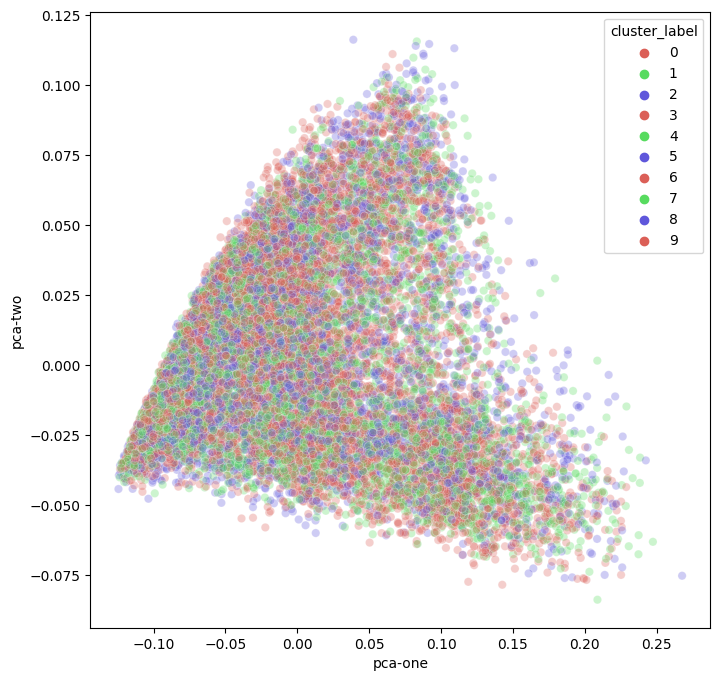

In [18]:
# plot the PCA result
plt.figure(figsize=(8,8))
ax = sns.scatterplot(
    x="pca-one", y="pca-two",
    hue="cluster_label",
    palette=sns.color_palette("hls", 3),
    data=df_sentences,
    legend="full",
    alpha=0.3
)